# Pose Estimation Algorithm
### Imports

In [498]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import trimesh
from mclasses.Pose import Pose
from mclasses.PoseObject import PoseObject
from mclasses.FilenamesHelper import FilenamesHelper

# Set up matplotlib for inline viewing
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Camera Calibrations

In [499]:
def load_camera_intrinsics():
    """Loads the RGB camera matrix from the calibrations file."""
    # Use your new helper to get the path
    calib_path = FilenamesHelper.get_camera_calibrations_file_path()

    fs = cv2.FileStorage(calib_path, cv2.FILE_STORAGE_READ)

    # Read the correct node
    camera_matrix = fs.getNode("rgb_calibration").mat()
    fs.release()

    # Assume zero distortion if not provided in the calibration file
    dist_coeffs = np.zeros((4, 1), dtype=np.float32)

    return camera_matrix, dist_coeffs

In [500]:
# Load intrinsics
K, dist_coeffs = load_camera_intrinsics()
print("Camera Matrix:\n", K)
print("Distortion Coefficients:\n", dist_coeffs)

Camera Matrix:
 [[575.81573   0.      319.5    ]
 [  0.      575.81573 239.5    ]
 [  0.        0.        1.     ]]
Distortion Coefficients:
 [[0.]
 [0.]
 [0.]
 [0.]]


In [501]:
def find_feature_matches(templ_gray, scn_gray):
    """Detects SIFT features and filters them using Lowe's Ratio Test."""
    sift = cv2.SIFT_create()
    kp_temp, des_temp = sift.detectAndCompute(templ_gray, None)
    kp_scene, des_scene = sift.detectAndCompute(scn_gray, None)

    # Notice crossCheck=False, because knnMatch needs to find the top 2 matches
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raw_matches = bf.knnMatch(des_temp, des_scene, k=2)

    good_matches = []
    # Lowe's Ratio Test: Only keep the match if the best match is significantly
    # better (closer distance) than the second best match.
    for m, n in raw_matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    return kp_temp, kp_scene, good_matches

In [502]:
def draw_feature_matches(template_img, kp_temp, scene_img, kp_scene, matches):
    """Draws lines connecting the matched keypoints between the two images."""
    # OpenCV has a built-in function specifically for visualizing this!
    matched_vis = cv2.drawMatches(
        template_img, kp_temp,
        scene_img, kp_scene,
        matches, None,
        matchColor=(0, 255, 0), # Green lines for matches
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Display using matplotlib
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(matched_vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {len(matches)} SIFT Feature Matches")
    plt.axis('off')
    plt.show()

In [503]:
def generate_scene_point_cloud(rgb_img, depth_img, mask_img, K):
    """Converts a 2D depth map into a 3D point cloud using camera intrinsics."""
    # Apply mask so we only reconstruct the bin/object area
    masked_depth = cv2.bitwise_and(depth_img, depth_img, mask=mask_img)

    # The Rutgers Kinect dataset depth values are typically in millimeters.
    # We divide by 1000.0 to convert the depth values into METERS.
    depth_meters = masked_depth.astype(np.float32) / 1000.0

    # Extract camera matrix parameters
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    h, w = depth_meters.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))

    # Filter out pixels where depth is 0 (invalid data)
    valid = depth_meters > 0

    # Apply the pinhole camera equations
    z = depth_meters[valid]
    x = (u[valid] - cx) * z / fx
    y = (v[valid] - cy) * z / fy

    # Stack the arrays into a list of 3D coordinates (N, 3)
    points_3d = np.vstack((x, y, z)).T

    # Extract the corresponding RGB colors for visualization
    colors = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)[valid]

    # Create the trimesh PointCloud object
    scene_pc = trimesh.points.PointCloud(points_3d, colors=colors)
    return scene_pc, points_3d, depth_meters

In [504]:
def generate_model_point_cloud(obj_path, num_points=15000):
    """Loads a 3D CAD model and samples a point cloud from its surface."""
    # Load the mesh (make sure the .mtl file is in the same directory)
    mesh = trimesh.load(obj_path)

    # Sample 3D points across the faces of the mesh
    points_3d, face_indices = trimesh.sample.sample_surface(mesh, num_points)

    model_pc = trimesh.points.PointCloud(points_3d)
    return model_pc, mesh

In [505]:
def estimate_pose_from_matches_3d(kp_temp, kp_scene, matches, K, dist_coeffs, template_shape, cad_mesh):
    """
    Uses matched keypoints to estimate a coarse 6-DOF pose using PnP,
    scaling the 2D template into 3D metric coordinates using the CAD model.
    """
    if len(matches) < 4:
        print("Error: Not enough matches to compute pose.")
        return None, None

    # 1. Get the physical dimensions of the 3D model (in meters)
    # cad_mesh.extents returns [width_X, height_Y, depth_Z]
    physical_width = cad_mesh.extents[0]
    physical_height = cad_mesh.extents[1]

    # 2. Get the pixel dimensions of our 2D template image
    h_pix, w_pix = template_shape[:2]

    # 3. Calculate the conversion factor from pixels to meters
    scale_x = physical_width / w_pix
    scale_y = physical_height / h_pix

    # 4. Extract and convert matches to 3D metric coordinates
    obj_points_3d = []
    pts_scene = []

    for m in matches:
        # Get 2D pixel coordinates on the template
        u_temp, v_temp = kp_temp[m.queryIdx].pt

        # Convert to 3D metric coordinates AND center them around (0,0)
        # Centering is crucial because the 3D CAD model's origin (0,0,0) is usually its center!
        x_metric = (u_temp - w_pix / 2.0) * scale_x
        y_metric = (v_temp - h_pix / 2.0) * scale_y
        z_metric = 0.0 # Assuming the matched texture lies on the front flat face (Z=0)

        obj_points_3d.append([x_metric, y_metric, z_metric])

        # Get 2D pixel coordinates in the scene
        pts_scene.append(kp_scene[m.trainIdx].pt)

    obj_points_3d = np.float32(obj_points_3d)
    pts_scene = np.float32(pts_scene)

    # 5. Solve PnP to find the Coarse Initial Pose
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_points_3d, pts_scene, K, dist_coeffs,
        reprojectionError=5.0, iterationsCount=100
    )

    if success:
        # Convert the rotation vector into a 3x3 rotation matrix
        R_est, _ = cv2.Rodrigues(rvec)
        return R_est, tvec
    else:
        print("Pose estimation failed to find enough inliers.")
        return None, None

In [506]:
def get_robust_initial_pose(scene_pc, R_pnp):
    """Overrides PnP translation by calculating the true 3D center of the object."""
    # 1. Calculate the centroid (average X, Y, Z) of the scene point cloud
    scene_points = np.array(scene_pc.vertices)
    scene_centroid = np.mean(scene_points, axis=0)

    # 2. Force the initial translation to be exactly at the center of the real object!
    t_robust = scene_centroid.reshape(3, 1)

    # 3. Keep PnP's rotation estimate. If PnP failed entirely, use an Identity matrix
    # so ICP starts with the box facing straight forward.
    R_robust = R_pnp if R_pnp is not None else np.eye(3)

    return R_robust, t_robust

In [507]:
def calculate_pose_error(R_est, t_est, gt_pose: Pose):
    """Calculates L2 Translational Error (meters) and Angular Rotational Error (degrees)."""
    # 1. Translational Error (L2 Euclidean Distance)
    # Ensure t_est is a 3x1 vector to match gt_pose.translation
    t_est = np.array(t_est).reshape(3, 1)
    gt_t = np.array(gt_pose.translation).reshape(3, 1)

    trans_error_meters = np.linalg.norm(t_est - gt_t)

    # 2. Rotational Error (Angle distance)
    R_gt = gt_pose.rotation
    R_diff = np.dot(R_est, R_gt.T)
    trace = np.trace(R_diff)

    # Clip trace to [-1, 3] to avoid math domain errors due to floating point precision
    trace = np.clip(trace, -1.0, 3.0)
    rot_error_rad = math.acos((trace - 1.0) / 2.0)
    rot_error_deg = math.degrees(rot_error_rad)

    return trans_error_meters, rot_error_deg

In [508]:
def refine_pose_icp_tweaked(model_pc, scene_pc, R_initial, t_initial):
    """Runs a higher-iteration ICP for fine rotational snapping."""
    model_points = np.array(model_pc.vertices)
    scene_points = np.array(scene_pc.vertices)

    initial_transform = np.eye(4)
    initial_transform[0:3, 0:3] = R_initial
    initial_transform[0:3, 3:4] = t_initial.reshape(3, 1)

    print("Running Tweaked ICP Registration... ")

    # Increased max_iterations to 100 for better rotational solving
    icp_matrix, transformed_points, cost = trimesh.registration.icp(
        model_points,
        scene_points,
        initial=initial_transform,
        threshold=1e-6, # Tighter threshold
        max_iterations=100
    )

    R_refined = icp_matrix[0:3, 0:3]
    t_refined = icp_matrix[0:3, 3:4]

    aligned_model_pc = trimesh.points.PointCloud(transformed_points)
    aligned_model_pc.colors = [255, 0, 0, 255]

    return R_refined, t_refined, aligned_model_pc

In [548]:
def process_pipeline(target_filename: str, visualize_loaded_files: bool = False, visualize_matches: bool = False):
    obj_data = PoseObject(target_filename, 2)

    # Load the images using the new FilenamesHelper paths
    rgb_img = cv2.imread(FilenamesHelper.get_image_file_path(obj_data))
    depth_img = cv2.imread(FilenamesHelper.get_depth_file_path(obj_data), cv2.IMREAD_UNCHANGED)
    mask_img = cv2.imread(FilenamesHelper.get_mask_file_path(obj_data), cv2.IMREAD_GRAYSCALE)

    # Load the texture using the new FilenamesHelper
    template_img = cv2.imread(FilenamesHelper.get_texture_file_path(obj_data))

    # Convert RGB to Grayscale for feature matching
    scene_gray = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)

    # Apply the bin mask to the scene to ignore background clutter outside the bin
    masked_scene = cv2.bitwise_and(scene_gray, scene_gray, mask=mask_img)

    if visualize_loaded_files:
        # Quick visualization
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Object Template")
        ax[1].imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)); ax[1].set_title("Scene RGB")
        ax[2].imshow(masked_scene, cmap='gray'); ax[2].set_title("Masked Scene")
        plt.show()

    # Run the updated matcher
    kp_temp, kp_scene, good_matches = find_feature_matches(template_gray, masked_scene)
    print(f"Robust SIFT found {len(good_matches)} highly reliable matches!")

    if visualize_matches:
        # Draw the matches! We pass the color images here so the visualization looks nicer.
        draw_feature_matches(template_img, kp_temp, rgb_img, kp_scene, good_matches)

    scene_pc, scene_points_3d, depth_meters = generate_scene_point_cloud(rgb_img, depth_img, mask_img, K)
    print(f"Generated Scene Point Cloud with {len(scene_points_3d)} 3D points.")

    # Ensure you have your obj_data configured from our previous FilenamesHelper
    obj_file_path = FilenamesHelper.get_obj_file_path(obj_data)
    model_pc, cad_mesh = generate_model_point_cloud(obj_file_path)

    print(f"Generated Model Point Cloud with {len(model_pc.vertices)} 3D points.")

    R_est, t_est = estimate_pose_from_matches_3d(
        kp_temp,
        kp_scene,
        good_matches,
        K,
        dist_coeffs,
        template_gray.shape,
        cad_mesh
    )

    R_coarse, t_coarse = get_robust_initial_pose(scene_pc, R_est)
    print("Robust Centroid Translation Seed:\n", t_coarse)

    R_final, t_final, aligned_model = refine_pose_icp_tweaked(model_pc, scene_pc, R_coarse, t_coarse)

    t_err_final, r_err_final = calculate_pose_error(R_final, t_final, obj_data.pose)
    print(f"\n=== NEW PIPELINE ACCURACY ===")
    print(f"Translational Error: {t_err_final:.4f} meters")
    print(f"Rotational Error: {r_err_final:.4f} degrees")



In [555]:
# target_filename = "cheezit_big_original-image-F-1-3-3.png"
# target_filename = "crayola_64_ct-image-E-2-3-2.png"
# target_filename = "dr_browns_bottle_brush-image-H-2-3-3.png"
# target_filename = "highland_6539_self_stick_notes-image-C-3-2-2.png"
# target_filename = "sharpie_accent_tank_style_highlighters-image-D-3-3-3.png"
# target_filename = "mark_twain_huckleberry_finn-image-G-1-3-1.png"
target_filename = "cheezit_big_original-image-F-2-1-0.png"

process_pipeline(target_filename)

Robust SIFT found 48 highly reliable matches!
Generated Scene Point Cloud with 27834 3D points.
Generated Model Point Cloud with 15000 3D points.
Robust Centroid Translation Seed:
 [[-0.00530902]
 [ 0.06440175]
 [ 0.82723047]]
Running Tweaked ICP Registration... 

=== NEW PIPELINE ACCURACY ===
Translational Error: 0.2153 meters
Rotational Error: 180.0000 degrees


Divided code

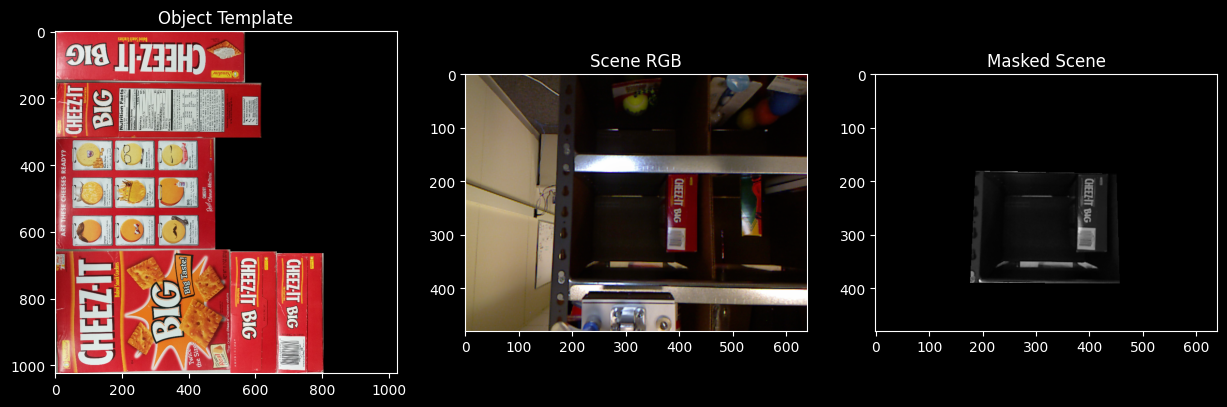

In [511]:
# The base filename (without path)
target_filename = "cheezit_big_original-image-F-1-3-2.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"
# target_filename = "kong_duck_dog_toy-image-A-1-2-0.png"

# Initialize our object. Note: PoseObject's __init__ will automatically use
# FilenamesHelper to find and load the ground truth pose!
# obj_data = PoseObject(target_filename, 1)
obj_data = PoseObject(target_filename, 1)

# Load the images using the new FilenamesHelper paths
rgb_img = cv2.imread(FilenamesHelper.get_image_file_path(obj_data))
depth_img = cv2.imread(FilenamesHelper.get_depth_file_path(obj_data), cv2.IMREAD_UNCHANGED)
mask_img = cv2.imread(FilenamesHelper.get_mask_file_path(obj_data), cv2.IMREAD_GRAYSCALE)

# Load the texture using the new FilenamesHelper
template_img = cv2.imread(FilenamesHelper.get_texture_file_path(obj_data))

# Convert RGB to Grayscale for feature matching
scene_gray = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)

# Apply the bin mask to the scene to ignore background clutter outside the bin
masked_scene = cv2.bitwise_and(scene_gray, scene_gray, mask=mask_img)

# Quick visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Object Template")
ax[1].imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)); ax[1].set_title("Scene RGB")
ax[2].imshow(masked_scene, cmap='gray'); ax[2].set_title("Masked Scene")
plt.show()

In [512]:
# Run the updated matcher
kp_temp, kp_scene, good_matches = find_feature_matches(template_gray, masked_scene)
print(f"Robust SIFT found {len(good_matches)} highly reliable matches!")

Robust SIFT found 192 highly reliable matches!


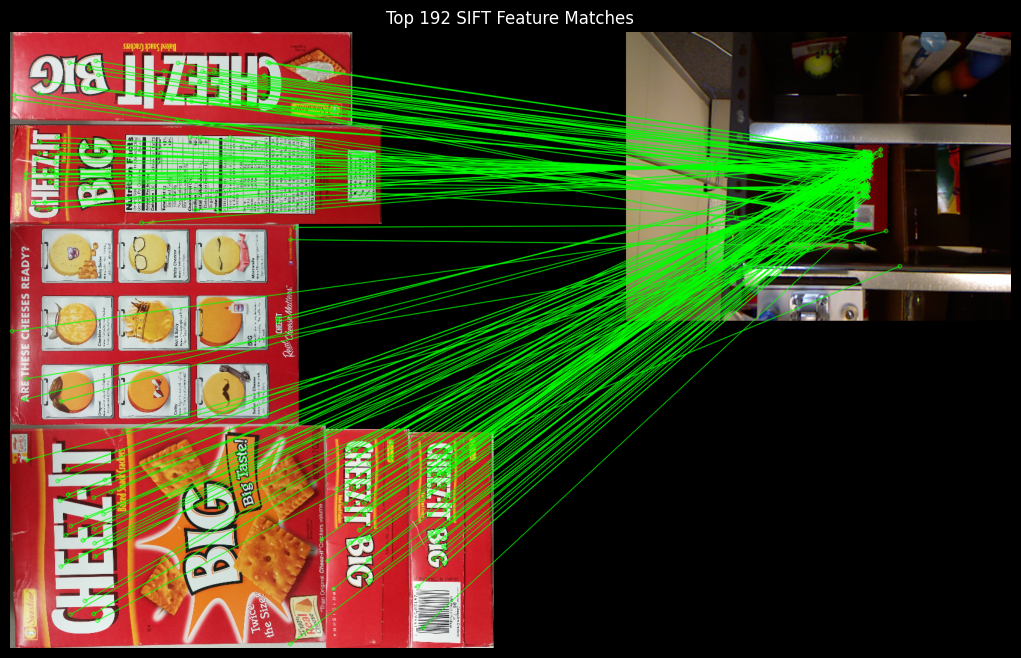

In [513]:
# Draw the matches! We pass the color images here so the visualization looks nicer.
draw_feature_matches(template_img, kp_temp, rgb_img, kp_scene, good_matches)

In [514]:
scene_pc, scene_points_3d, depth_meters = generate_scene_point_cloud(rgb_img, depth_img, mask_img, K)
print(f"Generated Scene Point Cloud with {len(scene_points_3d)} 3D points.")
# Uncomment the line below to open an interactive 3D viewer!
# scene_pc.show()

Generated Scene Point Cloud with 29821 3D points.


In [515]:
# Ensure you have your obj_data configured from our previous FilenamesHelper
obj_file_path = FilenamesHelper.get_obj_file_path(obj_data)
model_pc, cad_mesh = generate_model_point_cloud(obj_file_path)

print(f"Generated Model Point Cloud with {len(model_pc.vertices)} 3D points.")
# Uncomment the line below to see your 3D CAD model point cloud!
# model_pc.show()

Generated Model Point Cloud with 15000 3D points.


In [516]:
# --- Execution Step ---
# Call the updated function using our SIFT matches and the CAD mesh
R_est, t_est = estimate_pose_from_matches_3d(
    kp_temp,
    kp_scene,
    good_matches,
    K,
    dist_coeffs,
    template_gray.shape,
    cad_mesh
)

# if R_est is not None:
#     print("Coarse Estimated Translation Vector (in meters!):\n", t_est)
#     t_err_coarse, r_err_coarse = calculate_pose_error(R_est, t_est, obj_data.pose)
#     print(f"\n--- Coarse Accuracy Report ---")
#     print(f"Translational Error: {t_err_coarse:.4f} meters")
#     print(f"Rotational Error: {r_err_coarse:.4f} degrees")

In [517]:
# Run this AFTER your existing PnP cell
# Assuming you still have R_est from your PnP function:
R_coarse, t_coarse = get_robust_initial_pose(scene_pc, R_est)
print("Robust Centroid Translation Seed:\n", t_coarse)

Robust Centroid Translation Seed:
 [[-0.00214633]
 [ 0.06288141]
 [ 0.76331635]]


In [518]:
# Run the final tweaked ICP
R_final, t_final, aligned_model = refine_pose_icp_tweaked(model_pc, scene_pc, R_coarse, t_coarse)

Running Tweaked ICP Registration... 


In [519]:
print("Final Rotation", R_final)
print("Final Translation", t_final)

Final Rotation [[-0.28361712  1.93975296 -1.30555333]
 [ 0.22171936  1.33150793  1.93014944]
 [ 2.32764936  0.10952082 -0.34293343]]
Final Translation [[0.00473933]
 [0.05607671]
 [0.7591311 ]]


In [520]:
# Calculate final error
t_err_final, r_err_final = calculate_pose_error(R_final, t_final, obj_data.pose)
print(f"\n=== NEW PIPELINE ACCURACY ===")
print(f"Translational Error: {t_err_final:.4f} meters")
print(f"Rotational Error: {r_err_final:.4f} degrees")


=== NEW PIPELINE ACCURACY ===
Translational Error: 0.1150 meters
Rotational Error: 82.1629 degrees
